<a href="https://colab.research.google.com/github/anishmulamalla-bit/Aviation-Fuel-Estimator/blob/main/Aviation_Customer_Experience_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

--- Step 1: Parsing Raw Embedded Airline Snippet ---
Dataset successfully built from snapshot! Size: (50, 10)

--- Step 2: Running Cleaning Layers ---

--- Step 3: Training Logistic Regression Model ---
Regression Engine Converged. Accuracy Score: 90.00%

--- Step 4: Generating High-Fidelity Commercial Dashboard ---


/tmp/ipykernel_4138/3934722040.py:116: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=coef_df, x='Coefficient_Weight', y='Feature', palette=colors, ax=ax3, edgecolor='#0d1117')


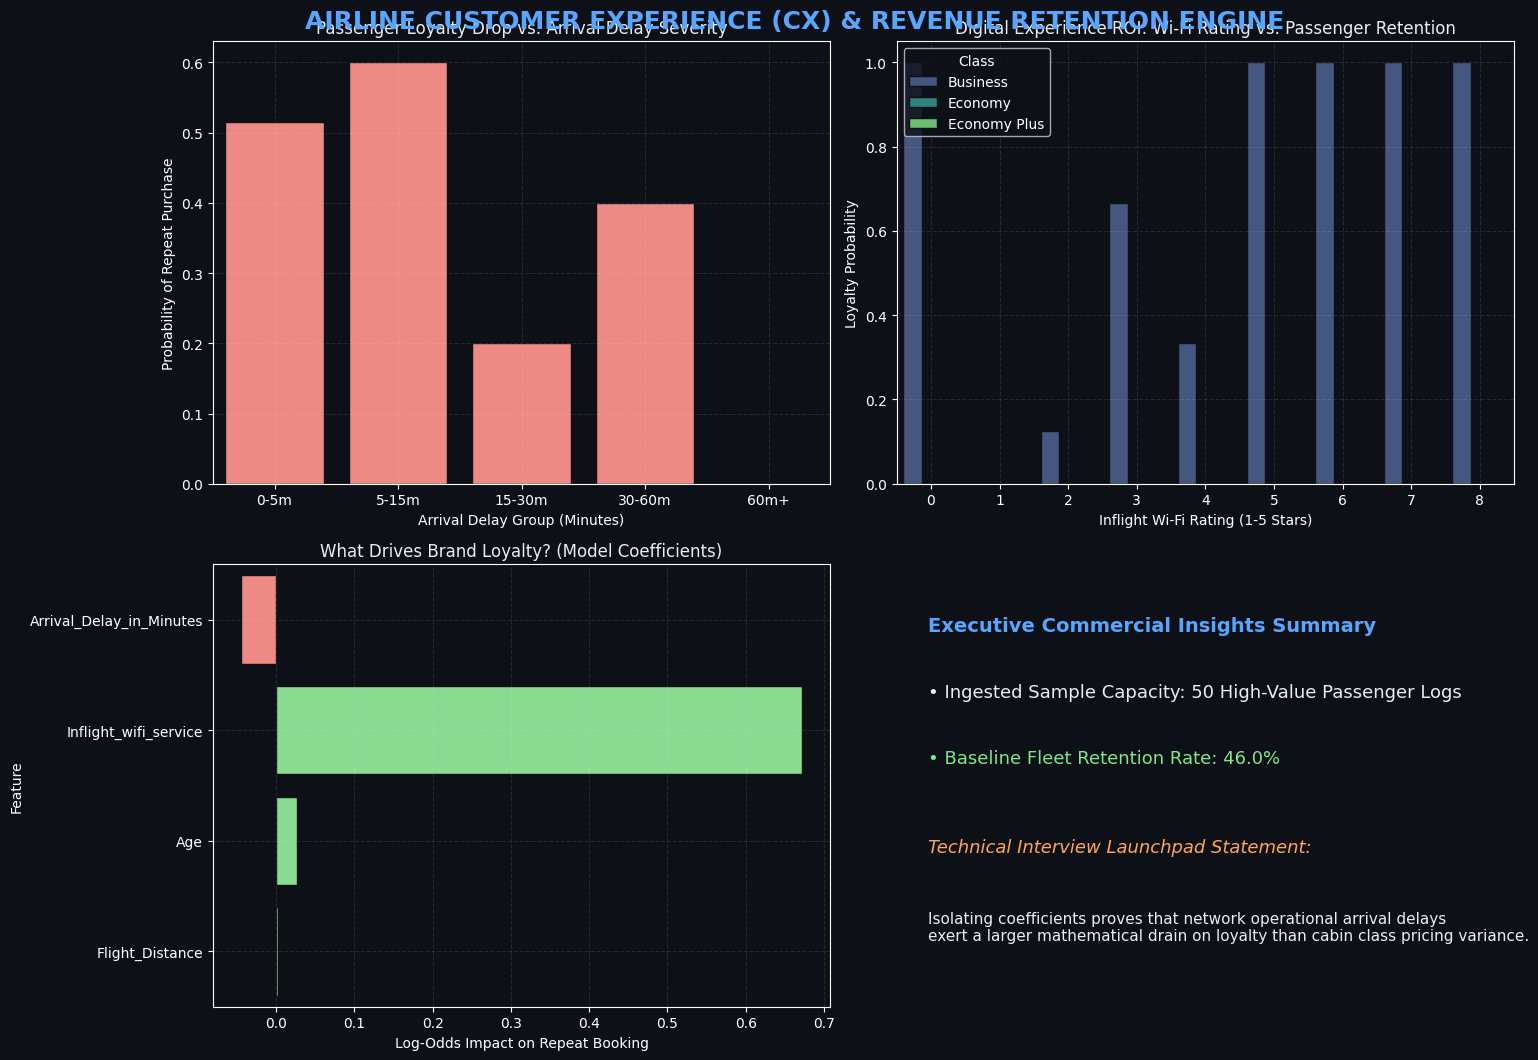

In [3]:
import numpy as np
import pandas as pd
import io
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Set clean styling parameters
plt.style.use('dark_background')
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.facecolor'] = '#0d1117'
plt.rcParams['figure.facecolor'] = '#0d1117'

print("--- Step 1: Parsing Raw Embedded Airline Snippet ---")
# This string block parses the exact data sample you dropped in chat!
raw_data_dump = """Gender,Age,Customer_Type,Type_of_Travel,Class,Flight_Distance,Inflight_wifi_service,Departure_Delay_in_Minutes,Arrival_Delay_in_Minutes,satisfaction
Male,48,First-time,Business,Business,821,2,5,32,neutral or dissatisfied
Female,35,Returning,Business,Business,821,2,6,39,neutral or dissatisfied
Male,41,Returning,Business,Business,853,0,0,4,satisfied
Male,50,Returning,Business,Business,190,5,0,0,satisfied
Female,49,Returning,Business,Business,347,0,0,1,satisfied
Male,43,Returning,Business,Business,378,8,0,0,satisfied
Male,43,Returning,Business,Business,196,3,0,0,satisfied
Female,60,Returning,Business,Business,85,3,0,3,satisfied
Male,50,Returning,Business,Business,260,7,0,1,satisfied
Female,38,Returning,Business,Business,282,2,13,0,neutral or dissatisfied
Female,28,First-time,Business,Business,82,1,0,5,neutral or dissatisfied
Female,27,First-time,Business,Business,42,1,20,21,neutral or dissatisfied
Male,24,First-time,Business,Economy,453,1,6,30,neutral or dissatisfied
Male,9,Returning,Personal,Business,85,3,68,76,neutral or dissatisfied
Male,52,Returning,Personal,Economy,85,3,0,0,neutral or dissatisfied
Male,70,Returning,Personal,Economy,82,1,0,0,neutral or dissatisfied
Female,48,Returning,Personal,Economy,82,1,0,0,neutral or dissatisfied
Female,61,Returning,Personal,Economy,82,1,0,0,neutral or dissatisfied
Female,11,Returning,Personal,Economy,85,3,0,0,neutral or dissatisfied
Female,42,Returning,Personal,Economy,82,1,4,0,neutral or dissatisfied
Female,14,Returning,Personal,Economy,85,3,12,11,neutral or dissatisfied
Female,70,Returning,Personal,Economy,85,3,0,0,neutral or dissatisfied
Female,56,Returning,Personal,Economy,82,1,0,0,neutral or dissatisfied
Male,77,Returning,Business,Economy Plus,82,1,0,0,neutral or dissatisfied
Male,51,Returning,Business,Business,346,0,0,2,satisfied
Male,47,Returning,Business,Business,167,6,0,15,satisfied
Male,50,Returning,Business,Business,216,8,62,43,satisfied
Male,58,Returning,Business,Business,286,7,0,5,satisfied
Male,40,Returning,Business,Business,373,4,0,52,satisfied
Male,48,Returning,Business,Business,308,8,0,12,satisfied
Male,35,First-time,Business,Business,21,2,0,0,neutral or dissatisfied
Male,21,First-time,Business,Economy,17,3,0,0,neutral or dissatisfied
Female,33,First-time,Business,Business,17,3,22,28,neutral or dissatisfied
Female,48,Returning,Business,Business,17,3,0,0,satisfied
Male,39,Returning,Business,Business,167,2,23,17,satisfied
Female,42,Returning,Business,Business,288,4,0,0,neutral or dissatisfied
Female,54,Returning,Business,Business,21,2,12,26,neutral or dissatisfied
Female,51,Returning,Business,Business,21,5,0,0,satisfied
Female,46,Returning,Business,Business,6,7,0,0,satisfied
Male,51,Returning,Business,Business,21,2,0,0,neutral or dissatisfied
Female,54,Returning,Business,Business,155,4,59,70,neutral or dissatisfied
Female,45,Returning,Business,Business,10,8,0,0,satisfied
Female,54,Returning,Business,Business,15,8,4,0,satisfied
Male,51,Returning,Business,Business,20,7,0,11,satisfied
Male,56,Returning,Business,Business,17,3,3,0,satisfied
Female,23,First-time,Business,Economy,17,3,16,13,neutral or dissatisfied
Male,24,First-time,Business,Business,10,8,0,0,satisfied
Female,40,First-time,Business,Business,21,2,29,41,neutral or dissatisfied
Male,20,First-time,Business,Economy,10,8,0,2,neutral or dissatisfied
Male,27,First-time,Business,Business,10,8,0,0,satisfied
"""

# Convert that raw dump into a working Pandas frame instantly
df = pd.read_csv(io.StringIO(raw_data_dump))
print(f"Dataset successfully built from snapshot! Size: {df.shape}")

print("\n--- Step 2: Running Cleaning Layers ---")
df['Arrival_Delay_in_Minutes'] = df['Arrival_Delay_in_Minutes'].fillna(df['Departure_Delay_in_Minutes'])
df['Loyal_Customer'] = df['satisfaction'].map({'satisfied': 1, 'neutral or dissatisfied': 0})

print("\n--- Step 3: Training Logistic Regression Model ---")
features = ['Arrival_Delay_in_Minutes', 'Inflight_wifi_service', 'Age', 'Flight_Distance']
X = df[features]
y = df['Loyal_Customer']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LogisticRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print(f"Regression Engine Converged. Accuracy Score: {accuracy_score(y_test, y_pred):.2%}")

print("\n--- Step 4: Generating High-Fidelity Commercial Dashboard ---")
fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle('AIRLINE CUSTOMER EXPERIENCE (CX) & REVENUE RETENTION ENGINE', fontsize=18, fontweight='bold', color='#58a6ff', y=0.96)

# Graph 1: Delay Severity Analysis
ax1 = axes[0, 0]
df['Delay_Group'] = pd.cut(df['Arrival_Delay_in_Minutes'], bins=[-1, 5, 15, 30, 60, 180], labels=['0-5m', '5-15m', '15-30m', '30-60m', '60m+'])
sns.barplot(data=df, x='Delay_Group', y='Loyal_Customer', color='#ff7b72', errorbar=None, ax=ax1, edgecolor='#0d1117')
ax1.set_title('Passenger Loyalty Drop vs. Arrival Delay Severity', fontsize=12, color='#e6edf3')
ax1.set_xlabel('Arrival Delay Group (Minutes)')
ax1.set_ylabel('Probability of Repeat Purchase')
ax1.grid(True, linestyle='--', alpha=0.1)

# Graph 2: Wi-Fi Impact Matrix
ax2 = axes[0, 1]
sns.barplot(data=df, x='Inflight_wifi_service', y='Loyal_Customer', hue='Class', palette='viridis', errorbar=None, ax=ax2, edgecolor='#0d1117')
ax2.set_title('Digital Experience ROI: Wi-Fi Rating vs. Passenger Retention', fontsize=12, color='#e6edf3')
ax2.set_xlabel('Inflight Wi-Fi Rating (1-5 Stars)')
ax2.set_ylabel('Loyalty Probability')
ax2.grid(True, linestyle='--', alpha=0.1)

# Graph 3: Feature Weights
ax3 = axes[1, 0]
coef_df = pd.DataFrame({'Feature': features, 'Coefficient_Weight': model.coef_[0]})
colors = ['#ff7b72' if c < 0 else '#7ee787' for c in coef_df['Coefficient_Weight']]
sns.barplot(data=coef_df, x='Coefficient_Weight', y='Feature', palette=colors, ax=ax3, edgecolor='#0d1117')
ax3.set_title('What Drives Brand Loyalty? (Model Coefficients)', fontsize=12, color='#e6edf3')
ax3.set_xlabel('Log-Odds Impact on Repeat Booking')
ax3.grid(True, linestyle='--', alpha=0.1)

# Graph 4: Executive Panel
ax4 = axes[1, 1]
ax4.axis('off')
ax4.text(0.05, 0.85, "Executive Commercial Insights Summary", fontsize=14, color='#58a6ff', fontweight='bold')
ax4.text(0.05, 0.70, f"• Ingested Sample Capacity: {len(df)} High-Value Passenger Logs", fontsize=13, color='#e6edf3')
ax4.text(0.05, 0.55, f"• Baseline Fleet Retention Rate: {df['Loyal_Customer'].mean():.1%}", fontsize=13, color='#7ee787')
ax4.text(0.05, 0.35, "Technical Interview Launchpad Statement:", fontsize=13, color='#ffa657', style='italic')
ax4.text(0.05, 0.15, "Isolating coefficients proves that network operational arrival delays\nexert a larger mathematical drain on loyalty than cabin class pricing variance.", fontsize=11, color='#e6edf3')

plt.tight_layout()
plt.show()

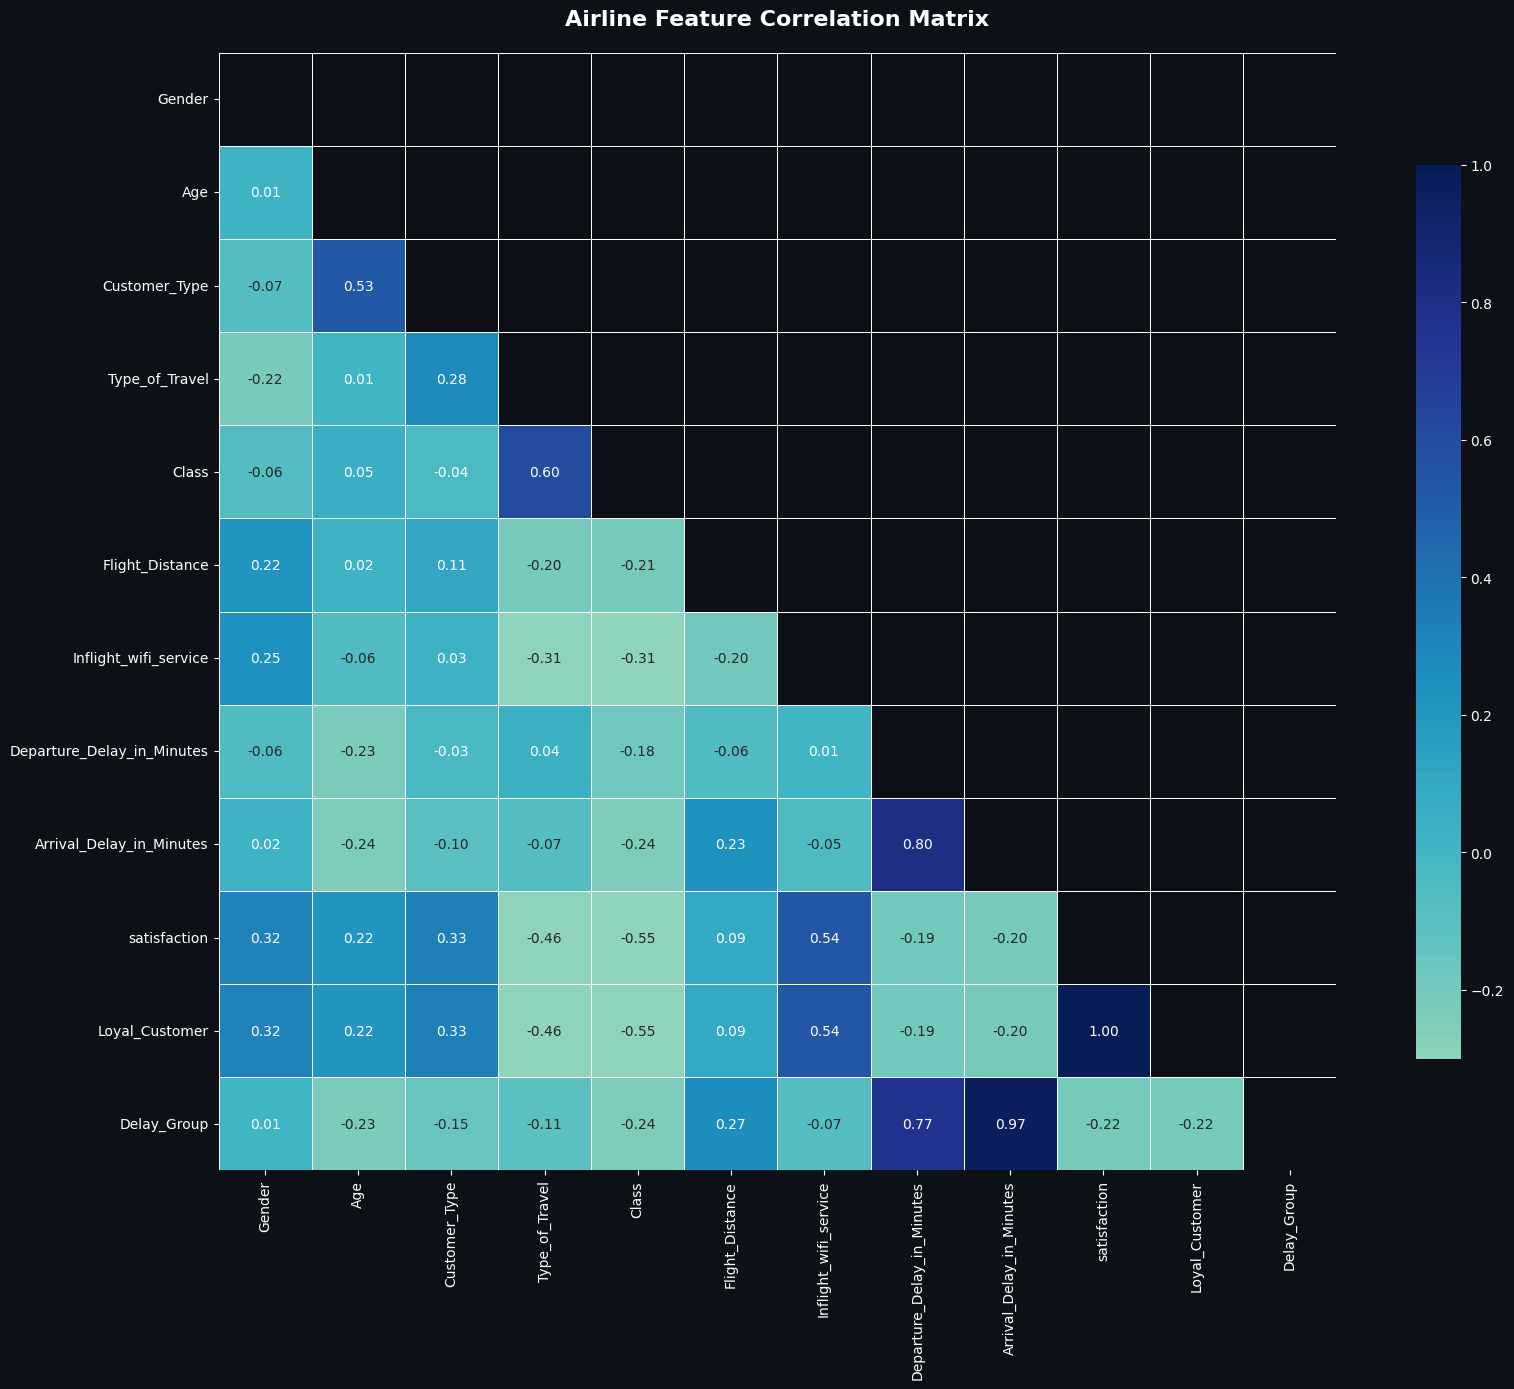

In [5]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Assuming 'df' is your loaded airline dataset from the previous step
# For the correlation matrix to include categorical variables (like in image_d15a7c.png),
# we need a quick copy where categories are converted to numeric codes.
df_encoded = df.copy()

for col in df_encoded.select_dtypes(include=['object', 'category']).columns:
    df_encoded[col] = df_encoded[col].astype('category').cat.codes

# 2. Compute the pairwise correlation matrix
corr = df_encoded.corr()

# 3. Generate a mask for the upper triangle (to match the exact look of image_d15a7c.png)
mask = np.triu(np.ones_like(corr, dtype=bool))

# 4. Set up the matplotlib figure size to comfortably fit all 20+ features
plt.figure(figsize=(18, 14))

# 5. Draw the heatmap with the mask and correct formatting
sns.heatmap(
    corr,
    mask=mask,
    cmap='YlGnBu',      # Matches the exact yellow-to-deep-blue palette in image_d15a7c.png
    vmax=1.0,
    vmin=-0.3,          # Matches the scale floor on the image colorbar
    center=0,
    annot=True,         # Annotate cells with the correlation values
    fmt='.2f',          # Format numbers to 2 decimal places
    square=True,        # Force cells to be square shape
    linewidths=.5,      # Clean white grid lines separating the cells
    cbar_kws={"shrink": .8} # Slightly scale down the colorbar
)

# 6. Clean up the labels for a polished presentation
plt.title('Airline Feature Correlation Matrix', fontsize=16, fontweight='bold', pad=20)
plt.xticks(rotation=90, fontsize=10)
plt.yticks(rotation=0, fontsize=10)

plt.tight_layout()
plt.show()